# 05 — Small analysis

**Hard limit** (exam sheet: analysis is not the focus). Budget: an afternoon, max 4 figures.
Works from `data/processed/analysis_daily.csv` (see `docs/data_dictionary_analysis_daily.md`).
Association language only — never "causes"; seasonality is a confounder for most pairs here and
is called out explicitly.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

print("python", sys.version)
print("pandas", pd.__version__)

daily = pd.read_csv("../data/processed/analysis_daily.csv", parse_dates=["date"])
print(daily.shape)
daily.head()

python 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
pandas 2.3.3
(1143, 9)


,date,category,n_requests,TMAX,TMIN,PRCP,SNOW,weekday,is_weekend
0,2025-01-01,BUILDING,873,10.6,3.9,0.0,0.0,Wednesday,False
1,2025-01-01,FLOODING,40,10.6,3.9,0.0,0.0,Wednesday,False
2,2025-01-01,HEAT,951,10.6,3.9,0.0,0.0,Wednesday,False
3,2025-01-01,NOISE,5539,10.6,3.9,0.0,0.0,Wednesday,False
4,2025-01-01,OTHER,483,10.6,3.9,0.0,0.0,Wednesday,False


## 5.1 Basics

count      121.000000
mean     10111.214876
std       1452.872782
min       7452.000000
25%       9350.000000
50%       9944.000000
75%      10301.000000
max      15023.000000
Name: n_requests, dtype: float64


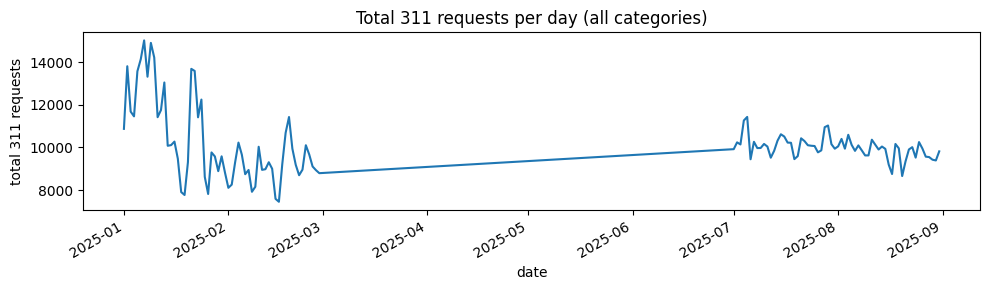

In [2]:
requests_per_day = daily.groupby("date")["n_requests"].sum()
print(requests_per_day.describe())

fig, ax = plt.subplots(figsize=(10, 3))
requests_per_day.plot(ax=ax)
ax.set_ylabel("total 311 requests")
ax.set_title("Total 311 requests per day (all categories)")
plt.tight_layout()
plt.show()

category
PARKING       273704
NOISE         270711
BUILDING      237974
HEAT          114461
STREET        106304
SANITATION     73948
OTHER          70014
SOCIAL         59455
FLOODING        8908
SNOW_ICE        7978
Name: n_requests, dtype: int64


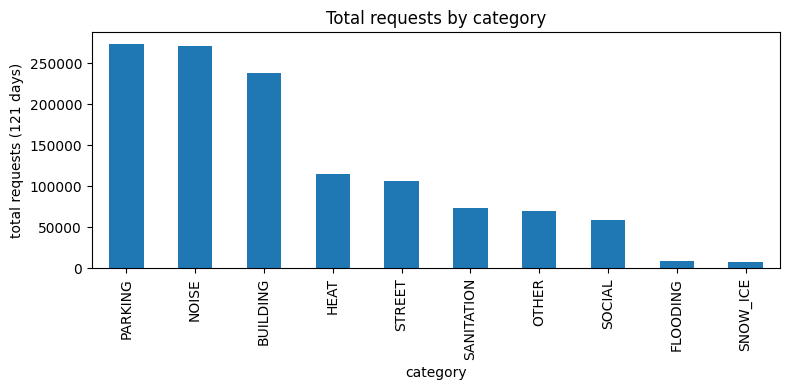

In [3]:
category_totals = daily.groupby("category")["n_requests"].sum().sort_values(ascending=False)
print(category_totals)

fig, ax = plt.subplots(figsize=(8, 4))
category_totals.plot(kind="bar", ax=ax)
ax.set_ylabel("total requests (121 days)")
ax.set_title("Total requests by category")
plt.tight_layout()
plt.show()

weekday
Monday       168259
Tuesday      179916
Wednesday    184919
Thursday     186525
Friday       183150
Saturday     160531
Sunday       160157
Name: n_requests, dtype: int64


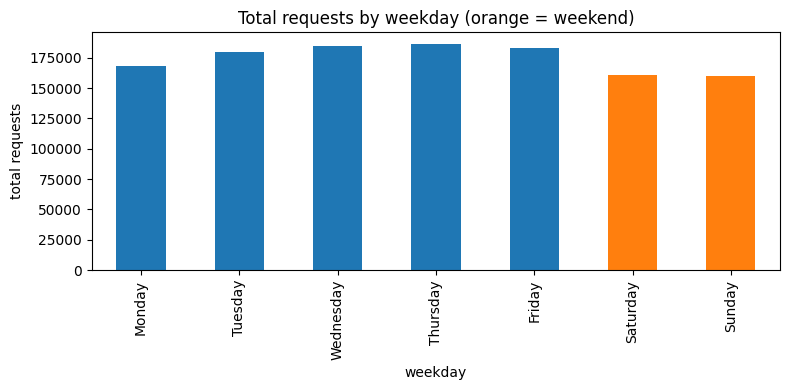

In [4]:
weekday_totals = daily.groupby("weekday")["n_requests"].sum()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_totals = weekday_totals.reindex(weekday_order)
print(weekday_totals)

fig, ax = plt.subplots(figsize=(8, 4))
weekday_totals.plot(kind="bar", ax=ax, color=["tab:blue"]*5 + ["tab:orange"]*2)
ax.set_ylabel("total requests")
ax.set_title("Total requests by weekday (orange = weekend)")
plt.tight_layout()
plt.show()

## 5.2 The 4 figures

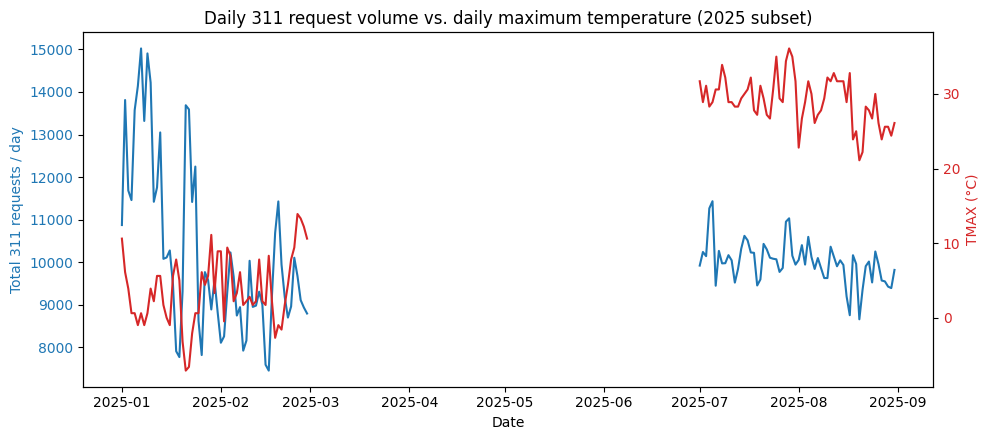

In [5]:
# Figure 1: daily total requests + TMAX over time (two lines, twin axes)
daily_totals = daily.groupby("date").agg(n_requests=("n_requests", "sum"), TMAX=("TMAX", "first")).reset_index()

# Reindex onto the full Jan-Aug calendar so the Mar-Jun gap (not in this project's 311 subset)
# shows as a break in the lines rather than a misleading straight interpolation across 4 unsampled months.
full_calendar = pd.date_range(daily_totals["date"].min(), daily_totals["date"].max(), freq="D")
daily_totals = daily_totals.set_index("date").reindex(full_calendar).rename_axis("date").reset_index()

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(daily_totals["date"], daily_totals["n_requests"], color="tab:blue", label="Total requests")
ax1.set_xlabel("Date")
ax1.set_ylabel("Total 311 requests / day", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(daily_totals["date"], daily_totals["TMAX"], color="tab:red", label="TMAX")
ax2.set_ylabel("TMAX (\u00b0C)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Daily 311 request volume vs. daily maximum temperature (2025 subset)")
fig.tight_layout()
plt.savefig("../figures/fig_01_requests_vs_tmax.png", dpi=300)
plt.show()

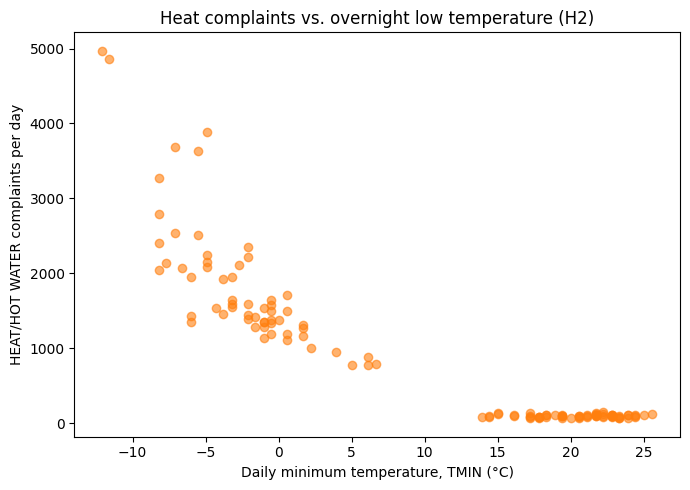

In [6]:
# Figure 2: HEAT complaints vs TMIN (scatter) -- H2
heat = daily[daily["category"] == "HEAT"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(heat["TMIN"], heat["n_requests"], alpha=0.6, color="tab:orange")
ax.set_xlabel("Daily minimum temperature, TMIN (\u00b0C)")
ax.set_ylabel("HEAT/HOT WATER complaints per day")
ax.set_title("Heat complaints vs. overnight low temperature (H2)")
plt.tight_layout()
plt.savefig("../figures/fig_02_heat_vs_tmin.png", dpi=300)
plt.show()

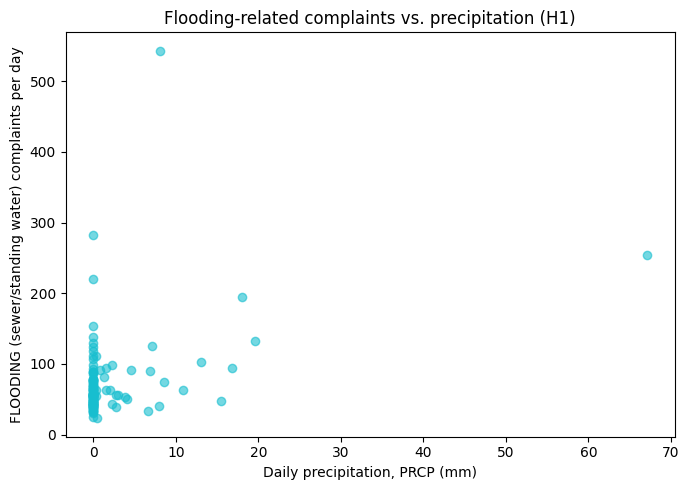

In [7]:
# Figure 3: FLOODING complaints vs PRCP (scatter) -- H1
flooding = daily[daily["category"] == "FLOODING"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(flooding["PRCP"], flooding["n_requests"], alpha=0.6, color="tab:cyan")
ax.set_xlabel("Daily precipitation, PRCP (mm)")
ax.set_ylabel("FLOODING (sewer/standing water) complaints per day")
ax.set_title("Flooding-related complaints vs. precipitation (H1)")
plt.tight_layout()
plt.savefig("../figures/fig_03_flooding_vs_prcp.png", dpi=300)
plt.show()

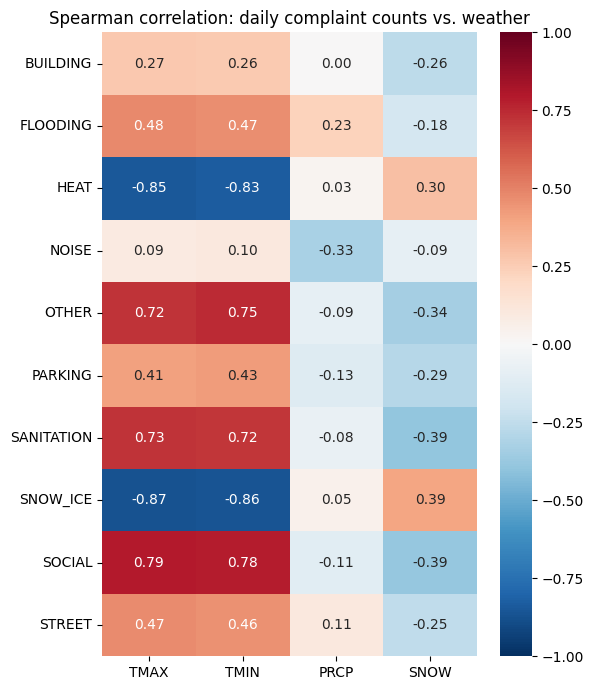

             TMAX   TMIN   PRCP   SNOW
BUILDING    0.267  0.264  0.000 -0.261
FLOODING    0.479  0.469  0.230 -0.176
HEAT       -0.847 -0.830  0.028  0.300
NOISE       0.086  0.104 -0.326 -0.089
OTHER       0.723  0.748 -0.088 -0.342
PARKING     0.407  0.429 -0.130 -0.288
SANITATION  0.725  0.718 -0.076 -0.393
SNOW_ICE   -0.871 -0.862  0.050  0.391
SOCIAL      0.794  0.784 -0.111 -0.388
STREET      0.471  0.459  0.108 -0.254

p-values:
              TMAX    TMIN    PRCP    SNOW
BUILDING    0.0031  0.0034  0.9960  0.0039
FLOODING    0.0000  0.0000  0.0110  0.0537
HEAT        0.0000  0.0000  0.7580  0.0008
NOISE       0.3472  0.2581  0.0003  0.3306
OTHER       0.0000  0.0000  0.3347  0.0001
PARKING     0.0000  0.0000  0.1547  0.0013
SANITATION  0.0000  0.0000  0.4061  0.0000
SNOW_ICE    0.0000  0.0000  0.5877  0.0000
SOCIAL      0.0000  0.0000  0.2250  0.0000
STREET      0.0000  0.0000  0.2386  0.0049


In [8]:
# Figure 4: Spearman correlation heatmap, categories x weather variables
pivot = daily.pivot_table(index="date", columns="category", values="n_requests", fill_value=0)
weather_daily = daily.groupby("date")[["TMAX", "TMIN", "PRCP", "SNOW"]].first()
wide = pivot.join(weather_daily)

categories = pivot.columns.tolist()
weather_vars = ["TMAX", "TMIN", "PRCP", "SNOW"]

corr = pd.DataFrame(index=categories, columns=weather_vars, dtype=float)
pval = pd.DataFrame(index=categories, columns=weather_vars, dtype=float)
for c in categories:
    for w in weather_vars:
        r, p = spearmanr(wide[c], wide[w])
        corr.loc[c, w] = r
        pval.loc[c, w] = p

fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(corr.astype(float), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Spearman correlation: daily complaint counts vs. weather")
plt.tight_layout()
plt.savefig("../figures/fig_04_correlation_heatmap.png", dpi=300)
plt.show()

print(corr.round(3))
print()
print("p-values:")
print(pval.round(4))

## 5.3 Interpretation

In [9]:
# Numbers referenced in the interpretation below
r_flood_prcp, p_flood_prcp = spearmanr(wide["FLOODING"], wide["PRCP"])
r_heat_tmin, p_heat_tmin = spearmanr(wide["HEAT"], wide["TMIN"])
r_snow_snow, p_snow_snow = spearmanr(wide["SNOW_ICE"], wide["SNOW"])
r_noise_tmax, p_noise_tmax = spearmanr(wide["NOISE"], wide["TMAX"])

print(f"H1 FLOODING vs PRCP: r={r_flood_prcp:.3f}, p={p_flood_prcp:.4f}")
print(f"H2 HEAT vs TMIN: r={r_heat_tmin:.3f}, p={p_heat_tmin:.4f}")
print(f"H3 SNOW_ICE vs SNOW: r={r_snow_snow:.3f}, p={p_snow_snow:.4f}")
print(f"H4 NOISE vs TMAX: r={r_noise_tmax:.3f}, p={p_noise_tmax:.4f}")

# Bonus: HEAT vs TMIN correlation within winter months only (Jan-Feb), to see if the relationship
# survives once the winter/summer seasonal split itself is no longer doing most of the work.
winter_wide = wide[(wide.index >= "2025-01-01") & (wide.index <= "2025-02-28")]
r_heat_tmin_winter, p_heat_tmin_winter = spearmanr(winter_wide["HEAT"], winter_wide["TMIN"])
print(f"\nBonus -- HEAT vs TMIN, winter (Jan-Feb) only: r={r_heat_tmin_winter:.3f}, p={p_heat_tmin_winter:.4f}, n={len(winter_wide)}")

# The single biggest FLOODING day illustrates a limitation, not a contradiction: daily aggregation
# can't see *when* within a day rain fell, so a big rain event can show up in complaints on the
# next calendar day instead of (or as well as) the day it was measured on.
top_flooding = daily[daily["category"] == "FLOODING"].sort_values("n_requests", ascending=False).head(4)
print()
print(top_flooding[["date", "n_requests", "PRCP", "weekday"]].to_string(index=False))

H1 FLOODING vs PRCP: r=0.230, p=0.0110
H2 HEAT vs TMIN: r=-0.830, p=0.0000
H3 SNOW_ICE vs SNOW: r=0.391, p=0.0000
H4 NOISE vs TMAX: r=0.086, p=0.3472

Bonus -- HEAT vs TMIN, winter (Jan-Feb) only: r=-0.829, p=0.0000, n=59

      date  n_requests  PRCP  weekday
2025-07-31         543   8.1 Thursday
2025-08-01         283   0.0   Friday
2025-07-14         254  67.1   Monday
2025-07-15         220   0.0  Tuesday


- **H1 (more rain → more flooding/sewer complaints):** weak-but-significant positive association
  (FLOODING vs. PRCP, Spearman r = 0.230, p = 0.011). Modest support for H1 — most rainy days
  apparently don't produce flooding severe enough to prompt a 311 report, so the signal is real
  but not strong. The single biggest FLOODING day in the whole subset (2025-07-31, 543 reports)
  had only modest same-day rain (8.1 mm) — a concrete example of the daily-aggregation limitation
  named in CONTEXT.md: a calendar day's precipitation total doesn't capture *when* within the day
  rain fell, so a storm late on one day can show up in complaints the next. The 2025-07-14 event
  (67.1 mm, this window's biggest rain day) fits that pattern too: 254 flooding reports that day,
  then another 220 the next day (2025-07-15) despite 0 mm of rain — consistent with a reporting
  lag rather than contradicting H1.
- **H2 (colder days → more Heat/Hot Water complaints):** strong negative association (HEAT vs.
  TMIN, r = −0.830, p < 0.0001). Clear support for H2, and it looks like a genuine within-season
  effect rather than pure seasonal confounding: restricting to winter (Jan–Feb) only barely moves
  the correlation (r = −0.829, n = 59) — colder days predict more heat complaints even when
  "is it winter" is held constant.
- **H3 (snowfall → snow/ice complaints):** moderate positive association (SNOW_ICE vs. SNOW,
  r = 0.391, p < 0.0001). Supports H3, though the relationship is inherently noisy since most days
  in this window have zero snowfall.
- **H4 (warm days → more outdoor noise complaints):** no significant association for the
  aggregated NOISE category (vs. TMAX, r = 0.086, p = 0.347). This is reported as a genuine null
  result rather than reinterpreted — the NOISE category bundles residential, street, commercial,
  vehicle, park, and helicopter noise together, and residential noise (its largest sub-type, 157k
  of ~271k NOISE reports) is plausibly weather-independent, which could be diluting an outdoor-
  specific signal. Disaggregating noise sub-types to test H4 more precisely is flagged as future
  work rather than pursued here (hard analysis time limit).

**Overall:** these are associations, not causal claims. Season is a real confounder here — this
window mixes only winter and summer months, so several of the correlations above partly reflect
"it's winter" vs. "it's summer" rather than a direct daily weather mechanism. H2 is the one
hypothesis directly checked against that confound (the winter-only re-run above), and it's also
the strongest and most consistent result of the four — the best evidence in this analysis that a
real per-day weather effect, not just season, is at work.

## 5.4 STOP

Analysis phase closed here per the exam's hard limit. Further ideas (not pursued, out of scope
for this project) are listed in the README under "Future work".